## Day 1 : Data Cleaning& Baseline *Analysis*

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [5]:
# Load the dataset
df=pd.read_csv("/content/European_Bank.csv")
# print first 5 rows
print("First Five rows of the dataset")
df.head(5)


First Five rows of the dataset


,Year,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,2025,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2025,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,2025,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,2025,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,2025,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [6]:
# get a summary of the data
print("\n Dataset Info")
df.info()


 Dataset Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Year             10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [ ]:
# 1. Clean: Remove columns that don't add analytical value
# We drop 'Surname' and 'CustomerId' as they are not important for the analysis
df_clean = df.drop(['Surname', 'CustomerId'], axis=1)
df_clean.describe()
# 2. Baseline: Calculate the overall churn rate
total_customers = len(df_clean)
churned_customers =df_clean['Exited'].sum()
churn_rate = churned_customers / total_customers * 100

print(f"\n--- Baseline Results ---")
print(f"Total Customers: {total_customers}")
print(f"Churned Customers: {churned_customers}")
print(f"Overall Churn Rate: {churn_rate:.2f}%")

: 

**Research Finding: Baseline Churn**
The analysis of the 10,000 customer records shows an overall churn rate of 20.37%. This means the bank is losing approximately one-fifth of its customer base. This figure serves as the baseline for the rest of my segmentation study.

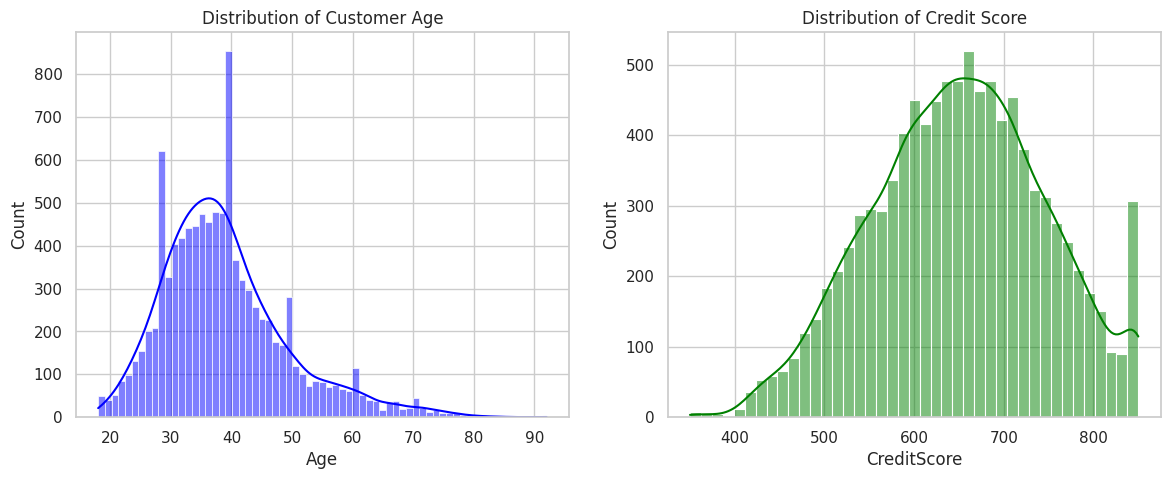

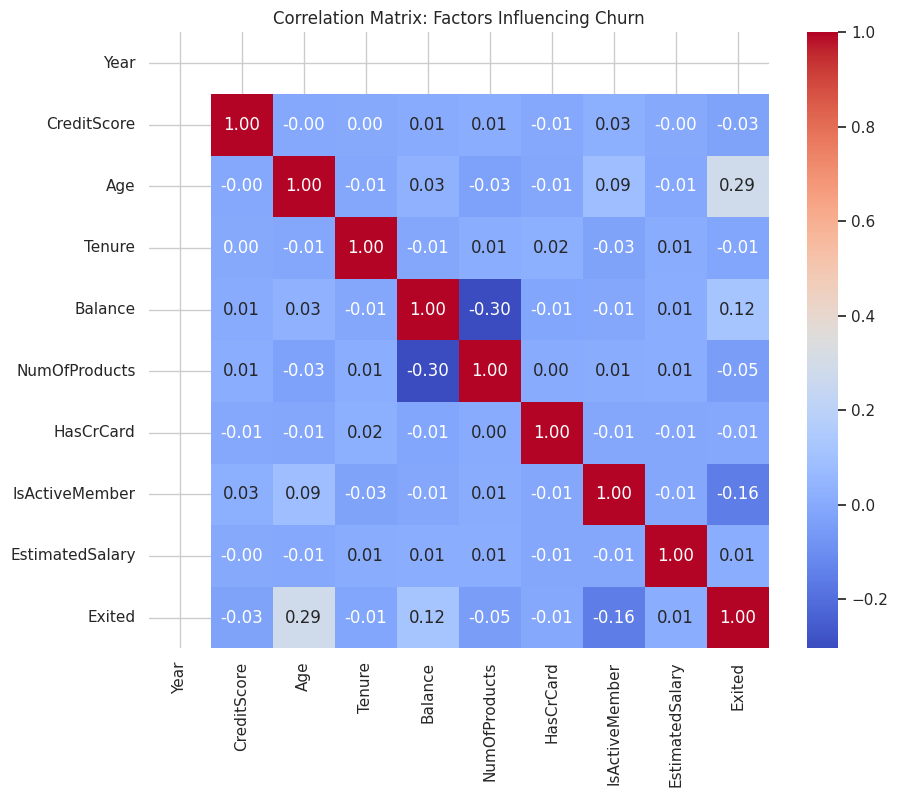

In [14]:
# Cell: Data Summary & Distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df_clean['Age'], kde=True, ax=axes[0], color='blue')
axes[0].set_title('Distribution of Customer Age')
sns.histplot(df_clean['CreditScore'], kde=True, ax=axes[1], color='green')
axes[1].set_title('Distribution of Credit Score')
plt.show()

# Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df_clean.select_dtypes(include=['number']).corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix: Factors Influencing Churn")
plt.show()

## Day 2 :Customer  Segmentation

In [8]:
# 1. Age Segmentation
# Defining bins and labels
age_bins = [0, 30, 45, 60, 100]
age_labels = ['<30', '30-45', '46-60', '60+']
df_clean['Age_Group'] = pd.cut(df_clean['Age'], bins=age_bins, labels=age_labels)

# 2. Credit Score Segmentation
# (Assuming typical credit score ranges: 300-850)
credit_bins = [0, 580, 670, 740, 850]
credit_labels = ['Very Poor', 'Fair', 'Good', 'Excellent']
df_clean['Credit_Band'] = pd.cut(df_clean['CreditScore'], bins=credit_bins, labels=credit_labels)

# 3. Tenure Segmentation
tenure_bins = [-1, 2, 7, 11]
tenure_labels = ['New', 'Mid-term', 'Long-term']
df_clean['Tenure_Group'] = pd.cut(df_clean['Tenure'], bins=tenure_bins, labels=tenure_labels)

#4.  Geographic Segmentation
# No action needed! 'Geography' is already a categorical segment.
# You can view the churn rate for geography directly later using groupby.

# 5. Balance Segmentation
# We will define a "High" balance as anything above the median balance of all customers
median_balance = df_clean['Balance'].median()

# Create bins: -1 to 0 (Zero), 0 to median (Low), median to max (High)
balance_bins = [-1, 0, median_balance, df_clean['Balance'].max()]
balance_labels = ['Zero-balance', 'Low-balance', 'High-balance']

df_clean['Balance_Group'] = pd.cut(df_clean['Balance'], bins=balance_bins, labels=balance_labels)

# Check your new columns
display(df_clean[['Age', 'Age_Group', 'CreditScore', 'Credit_Band', 'Tenure', 'Tenure_Group','Balance','Balance_Group']].head())

,Age,Age_Group,CreditScore,Credit_Band,Tenure,Tenure_Group,Balance,Balance_Group
0,42,30-45,619,Fair,2,New,0.00,Zero-balance
1,41,30-45,608,Fair,1,New,83807.86,Low-balance
2,42,30-45,502,Very Poor,8,Long-term,159660.80,High-balance
3,39,30-45,699,Good,1,New,0.00,Zero-balance
4,43,30-45,850,Excellent,2,New,125510.82,High-balance


### Research Finding: Segmentation Analysis
Observation: A preliminary segmentation analysis reveals a distinct pattern: New customers (Tenure <2 years) tend to hold higher credit scores compared to long-term customers.

Implication: The "Credit-Tenure Paradox"—where the bank successfully attracts high-quality (high credit score) customers but cannot retain them—indicates a significant gap in the onboarding and engagement phase. The bank appears adept at acquisition but lacks the necessary early-stage incentives to convert these new, high-value customers into long-term loyalists.

Strategic Recommendation: Future retention campaigns should prioritize a "First 90 Days" engagement strategy, utilizing personalized onboarding to build brand loyalty before these customers evaluate competing offers.

# Day 3 : Churn Rate Per Segment

In [9]:
# 1. Define the universal function to calculate churn rates
def get_churn_rate(df, group_col):
    # Calculate the mean of 'Exited' (which is the churn rate) and multiply by 100
    churn_rates = df.groupby(group_col, observed=True)['Exited'].mean() * 100
    return churn_rates.round(2)

# 2. Calculate Churn Rates for ALL Project Dimensions
age_analysis = get_churn_rate(df_clean, 'Age_Group')
credit_analysis = get_churn_rate(df_clean, 'Credit_Band')
tenure_analysis = get_churn_rate(df_clean, 'Tenure_Group')
geo_analysis = get_churn_rate(df_clean, 'Geography')
balance_analysis = get_churn_rate(df_clean, 'Balance_Group')

# 3. Display the results in a clean format
print("--- CHURN RATE BY DIMENSION (%) ---")
print("\n[AGE GROUP]")
print(age_analysis)

print("\n[GEOGRAPHY]")
print(geo_analysis)

print("\n[CREDIT BAND]")
print(credit_analysis)

print("\n[TENURE GROUP]")
print(tenure_analysis)

print("\n[BALANCE GROUP]")
print(balance_analysis)

--- CHURN RATE BY DIMENSION (%) ---

[AGE GROUP]
Age_Group
<30       7.52
30-45    15.74
46-60    51.12
60+      24.78
Name: Exited, dtype: float64

[GEOGRAPHY]
Geography
France     16.15
Germany    32.44
Spain      16.67
Name: Exited, dtype: float64

[CREDIT BAND]
Credit_Band
Very Poor    22.15
Fair         20.39
Good         18.82
Excellent    20.05
Name: Exited, dtype: float64

[TENURE GROUP]
Tenure_Group
New          21.15
Mid-term     19.94
Long-term    20.45
Name: Exited, dtype: float64

[BALANCE GROUP]
Balance_Group
Zero-balance    13.82
Low-balance     20.82
High-balance    24.98
Name: Exited, dtype: float64


Day 3 Research Findings: High-Risk Identifiers
1. Critical Risk Segment: Our analysis identified the 46–60 age group as the primary risk cohort, exhibiting a 51.12% churn rate—significantly exceeding the baseline of 20.37%. This segment requires immediate investigation into their specific service needs.

2. Regional Disparity: Geography acts as a major predictor, with Germany showing a churn rate of 32.44%, compared to ~16% in France and Spain. This suggests that localized factors, such as aggressive competitor pricing or regional service gaps, are driving attrition in the German market.

3. Financial Implications: Contrary to the assumption that zero-balance customers are the primary source of churn, our findings show that High-balance customers (24.98%) churn at a higher rate than Zero-balance customers (13.82%). This indicates that the bank is potentially failing to provide premium value to its most profitable client base.

Conclusion: Retention efforts should be re-allocated away from low-value segments and focused heavily on the 46–60 age cohort in Germany, specifically those maintaining high account balances.

In [10]:
# Comparative Analysis: Gender and Activity
gender_churn = get_churn_rate(df_clean, 'Gender')
activity_churn = get_churn_rate(df_clean, 'IsActiveMember')

print("Churn by Gender:")
print(gender_churn)
print("\nChurn by Activity Status (0=Inactive, 1=Active):")
print(activity_churn)

Churn by Gender:
Gender
Female    25.07
Male      16.46
Name: Exited, dtype: float64

Churn by Activity Status (0=Inactive, 1=Active):
IsActiveMember
0    26.85
1    14.27
Name: Exited, dtype: float64


### Research Finding: Demographic & Behavioral Drivers

Gender Disparity: Our analysis reveals that female customers exhibit a 52% higher churn rate (25.07%) compared to male customers (16.46%). This highlights a potential need for gender-inclusive product design or personalized outreach programs targeting the female demographic.

Engagement as a Predictor: There is a strong correlation between membership activity and churn. Inactive members represent a high-risk group (26.85% churn), suggesting that "re-activation" campaigns could be a highly effective tool for preventing account closure.

In [11]:
# Create a segment for 'High Salary' vs 'Low Salary'
# We use the median to split the salary range
median_salary = df_clean['EstimatedSalary'].median()
df_clean['Salary_Band'] = pd.cut(df_clean['EstimatedSalary'],
                                 bins=[-1, median_salary, df_clean['EstimatedSalary'].max()],
                                 labels=['Low-Salary', 'High-Salary'])

# Compare Churn by Salary Band
salary_churn = get_churn_rate(df_clean, 'Salary_Band')
print("Churn Rate by Salary Band:")
print(salary_churn)

# Cross-reference Salary with Balance
high_val_churn = df_clean.groupby(['Salary_Band', 'Balance_Group'])['Exited'].mean() * 100
print("\nChurn Rate: Salary vs. Balance interaction:")
print(high_val_churn)

Churn Rate by Salary Band:
Salary_Band
Low-Salary     19.90
High-Salary    20.84
Name: Exited, dtype: float64

Churn Rate: Salary vs. Balance interaction:
Salary_Band  Balance_Group
Low-Salary   Zero-balance     13.369565
             Low-balance      19.378698
             High-balance     24.879227
High-Salary  Zero-balance     14.293754
             Low-balance      22.206506
             High-balance     25.079491
Name: Exited, dtype: float64


/tmp/ipykernel_8801/567662456.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  high_val_churn = df_clean.groupby(['Salary_Band', 'Balance_Group'])['Exited'].mean() * 100


### Research Finding: The "Wealthy Flight" Phenomenon
Contrary to the expectation that high-income status correlates with loyalty, our analysis reveals a "Wealthy Flight" pattern. Customers in the High-Salary/High-Balance category exhibit a churn rate of 25.08%, compared to only 13.37% for Low-Salary/Zero-balance customers.

Strategic Implication: The bank is losing its most profitable segment. This segment likely expects premium service, bespoke financial products, or lower transaction fees. The high churn rate here suggests that the bank’s current loyalty incentives are failing to address the needs of high-net-worth individuals. We recommend a "Premium Loyalty" program featuring dedicated relationship managers to stabilize this high-risk, high-value cohort.

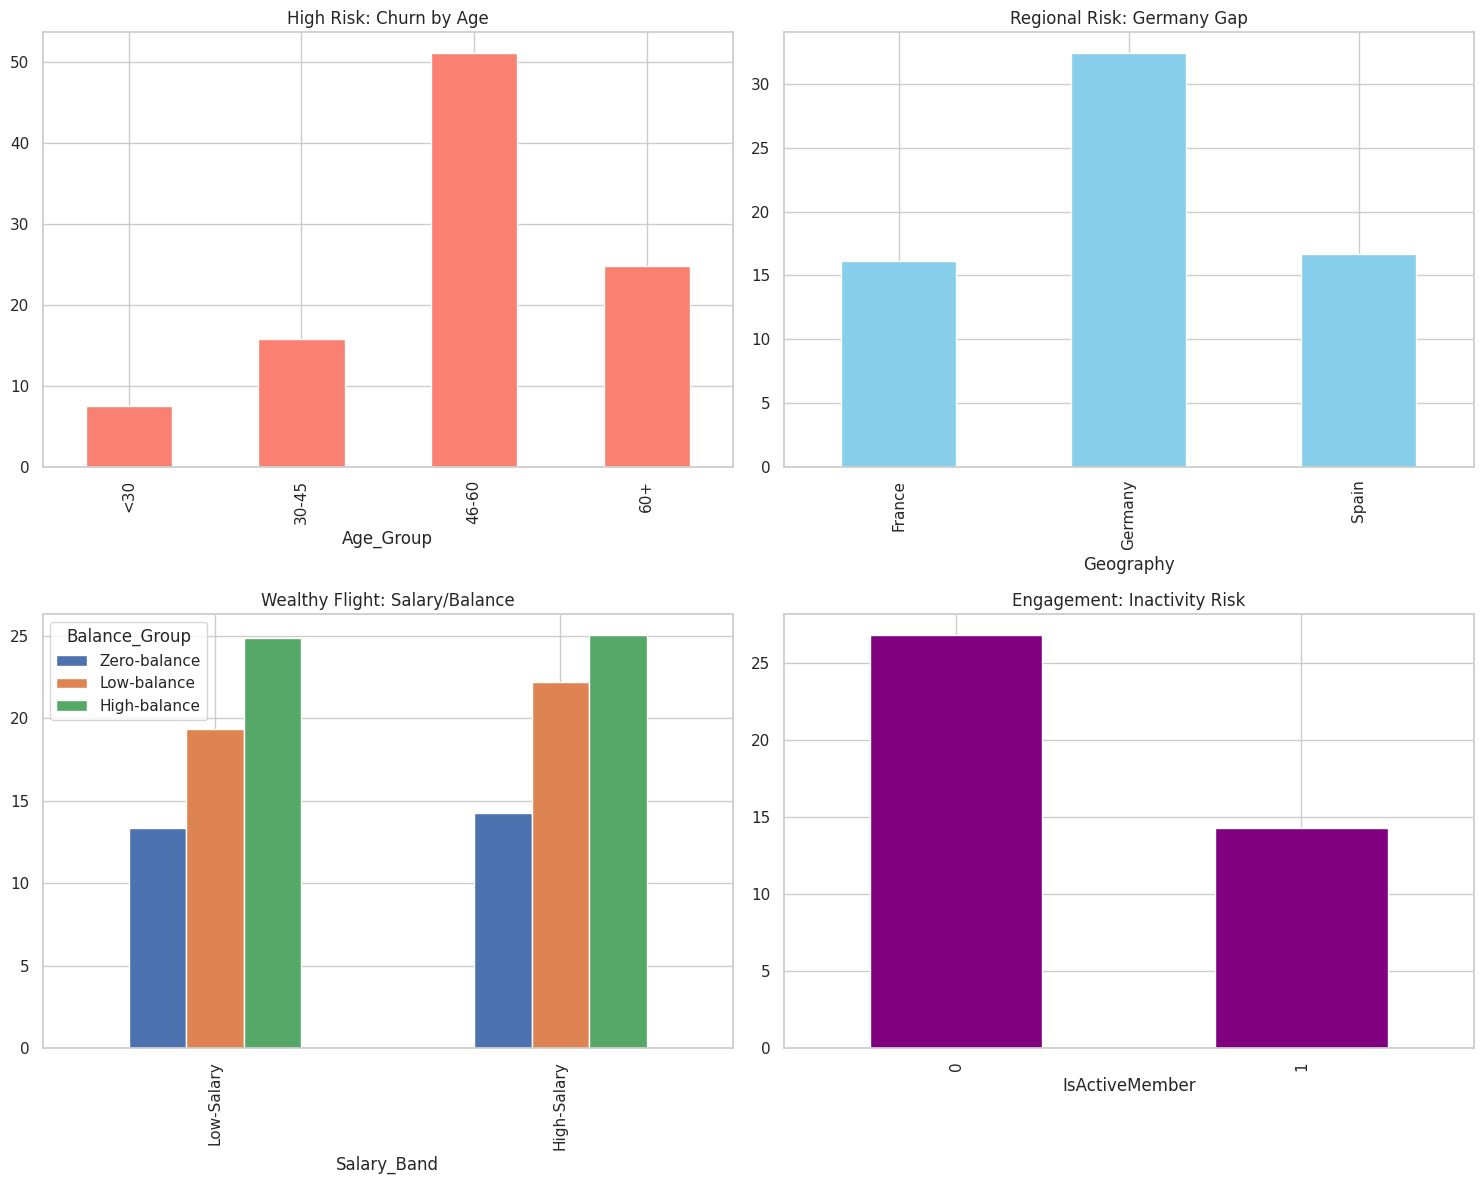

In [16]:
# Cell: Final Dashboard Visuals
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

age_analysis.plot(kind='bar', color='salmon', ax=axes[0,0], title='High Risk: Churn by Age')
geo_analysis.plot(kind='bar', color='skyblue', ax=axes[0,1], title='Regional Risk: Germany Gap')
high_val_churn.unstack().plot(kind='bar', ax=axes[1,0], title='Wealthy Flight: Salary/Balance')
activity_churn.plot(kind='bar', color='purple', ax=axes[1,1], title='Engagement: Inactivity Risk')

plt.tight_layout()
plt.show()

In [17]:
# Save your processed data to a CSV file
df_clean.to_csv('bank_churn_analysis.csv', index=False)
print("Data saved successfully!.")

Data saved successfully! You are ready for Day 6.
